In [53]:
"""
CELL 0: DEPENDENCY MANAGER (Run this first after any kernel restart)
Ensures all models, data, and functions are available regardless of execution order.
"""
from pathlib import Path
from keras.models import load_model

MODELS_DIR = Path("models")
ARTIFACTS_DIR = Path("artifacts")

# Ensure directories exist
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Directories ready")
print(f"  Models: {MODELS_DIR.resolve()}")
print(f"  Artifacts: {ARTIFACTS_DIR.resolve()}")

# Auto-load models from disk if they exist and aren't in memory
def ensure_lstm_model():
    if "lstm_model" not in globals():
        lstm_path = MODELS_DIR / "lstm_rul_model.keras"
        if lstm_path.exists():
            global lstm_model
            lstm_model = load_model(lstm_path)
            print("✓ Loaded LSTM model from disk")
        else:
            print("⚠ LSTM model not found. Run Cell: LSTM Training")
    return "lstm_model" in globals()

def ensure_gru_model():
    if "gru_model" not in globals():
        gru_path = MODELS_DIR / "gru_rul_model.keras"
        if gru_path.exists():
            global gru_model
            gru_model = load_model(gru_path)
            print("✓ Loaded GRU model from disk")
        else:
            print("⚠ GRU model not found. Run Cell: GRU Training")
    return "gru_model" in globals()

# Status check
lstm_ok = ensure_lstm_model()
gru_ok = ensure_gru_model()

if lstm_ok and gru_ok:
    print("\n✅ All models ready! You can run any cell.")
else:
    print("\n⚠️ Some models missing. Run training cells if this is first-time setup.")

✓ Directories ready
  Models: C:\PrognosAI\models
  Artifacts: C:\PrognosAI\artifacts

✅ All models ready! You can run any cell.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold

from keras.models import Sequential
from keras.layers import Input, LSTM, GRU, Dense, Dropout, BatchNormalization
from keras.callbacks import ReduceLROnPlateau
from keras.optimizers import Adam
from keras.regularizers import l2

In [2]:
fd1 = pd.read_csv("data/train_FD001.txt", sep=" ", header=None).dropna(axis=1)
fd2 = pd.read_csv("data/train_FD002.txt", sep=" ", header=None).dropna(axis=1)
fd3 = pd.read_csv("data/train_FD003.txt", sep=" ", header=None).dropna(axis=1)
fd4 = pd.read_csv("data/train_FD004.txt", sep=" ", header=None).dropna(axis=1)

In [3]:
columns = ["unit","cycle","op_setting_1","op_setting_2","op_setting_3"]

for i in range(1,22):
    columns.append(f"sensor_{i}")

for df in [fd1,fd2,fd3,fd4]:
    df.columns = columns

In [4]:
fd1["dataset"] = "FD001"
fd2["dataset"] = "FD002"
fd3["dataset"] = "FD003"
fd4["dataset"] = "FD004"

In [5]:
df = pd.concat([fd1,fd2,fd3,fd4], ignore_index=True)

print("Merged Dataset Shape:", df.shape)
df.head()

Merged Dataset Shape: (160359, 27)


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001


In [6]:
df["unit_id"] = df["dataset"] + "_" + df["unit"].astype(str)

In [7]:
max_cycle = df.groupby("unit_id")["cycle"].max().reset_index()
max_cycle.columns = ["unit_id","max_cycle"]

df = df.merge(max_cycle, on="unit_id")

df["RUL"] = df["max_cycle"] - df["cycle"]

df.drop(columns=["max_cycle"], inplace=True)

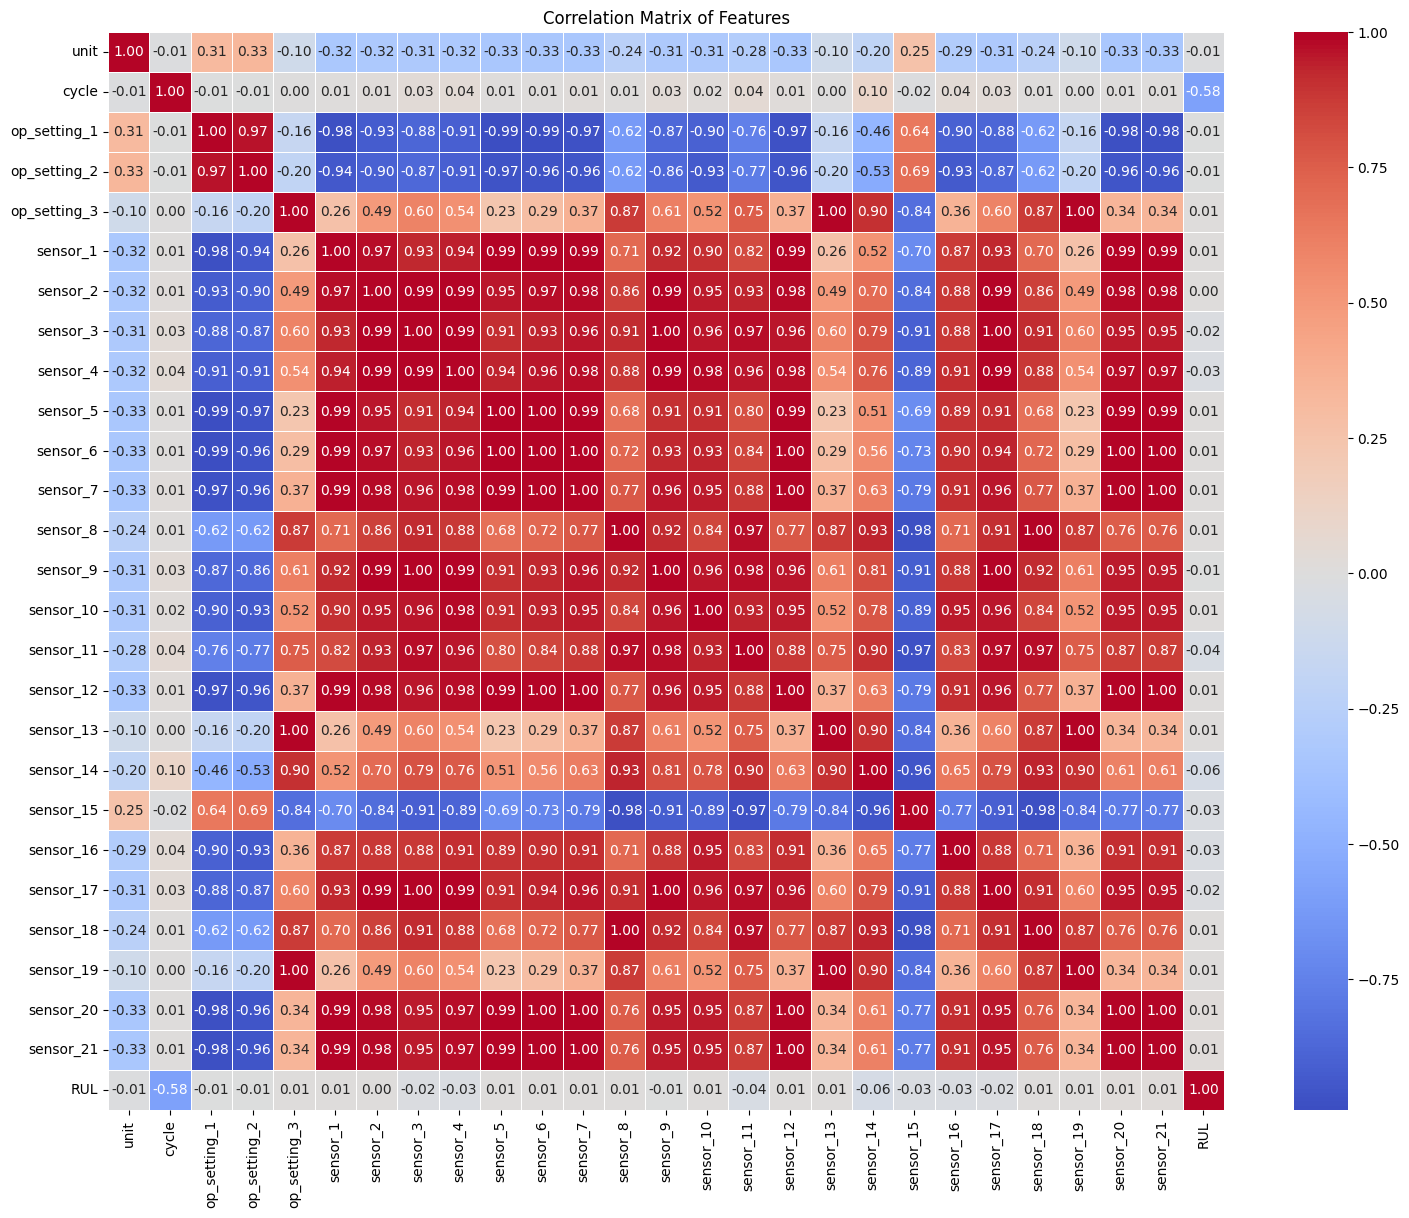

In [8]:
corr_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Features")
plt.show()

In [9]:
features = df.drop(columns=["dataset","unit_id","RUL"])

selector = VarianceThreshold(threshold=1e-2)
selector.fit(features)

selected_columns = features.columns[selector.get_support()]

df = df[selected_columns.tolist() + ["dataset","unit_id","RUL"]]

print("Remaining Features:", len(selected_columns))

Remaining Features: 25


In [10]:
engine_ids = df["unit_id"].unique()
rng = np.random.default_rng(42)
engine_ids = rng.permutation(engine_ids)

split = int(len(engine_ids) * 0.8)

train_engines = engine_ids[:split]
val_engines = engine_ids[split:]

train_df = df[df["unit_id"].isin(train_engines)].copy()
val_df = df[df["unit_id"].isin(val_engines)].copy()

In [11]:
feature_cols = train_df.drop(columns=["dataset","unit_id","RUL"]).columns

scaler = MinMaxScaler()

train_df[feature_cols] = train_df[feature_cols].astype(float)
val_df[feature_cols] = val_df[feature_cols].astype(float)

train_df.loc[:, feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df.loc[:, feature_cols] = scaler.transform(val_df[feature_cols])

In [12]:
MAX_RUL = 125

train_df["RUL"] = train_df["RUL"].clip(upper=MAX_RUL) / MAX_RUL
val_df["RUL"] = val_df["RUL"].clip(upper=MAX_RUL) / MAX_RUL

print("RUL range after normalization:")
print(f"  Train: {train_df['RUL'].min():.4f} – {train_df['RUL'].max():.4f}")
print(f"  Val  : {val_df['RUL'].min():.4f} – {val_df['RUL'].max():.4f}")

RUL range after normalization:
  Train: 0.0000 – 1.0000
  Val  : 0.0000 – 1.0000


In [13]:
window_size = 30
sequence_stride = 2

def create_sequences(data):

    X, y = [], []

    for uid in data["unit_id"].unique():

        engine = data[data["unit_id"] == uid]

        # Include the last valid window and use the last timestep label in each window.
        for i in range(0, len(engine) - window_size + 1, sequence_stride):

            X.append(
                engine[feature_cols]
                .iloc[i:i+window_size]
                .values
            )

            y.append(
                engine["RUL"].iloc[i+window_size-1]
            )

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [14]:
X_train, y_train = create_sequences(train_df)
X_val, y_val = create_sequences(val_df)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print(f"Window size: {window_size}, stride: {sequence_stride}")

Train Shape: (56377, 30, 25)
Validation Shape: (13694, 30, 25)
Window size: 30, stride: 2


In [15]:
optimizer = Adam(learning_rate=0.0005)

lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(256, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(128, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.4),

    LSTM(96, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(48, return_sequences=True, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dense(1)
])

lstm_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

import io
buf = io.StringIO()
lstm_model.summary(print_fn=lambda x: buf.write(x + "\n"))
print(buf.getvalue())

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 256)        │       288,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)     

In [49]:
from pathlib import Path
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model

# CHECK 1: Skip training if trained model already exists
lstm_path = Path("models/lstm_rul_model.keras")
if lstm_path.exists():
    lstm_model = load_model(lstm_path)
    print(f"✓ LSTM model already trained. Loaded from {lstm_path}")
    print("  (Training skipped; to retrain, delete the saved model file)")
else:
    # CHECK 2: Ensure training data is available
    required_training_arrays = ["X_train", "y_train", "X_val", "y_val"]
    missing_arrays = [name for name in required_training_arrays if name not in globals()]
    if missing_arrays:
        raise RuntimeError(
            "Missing training arrays: " + ", ".join(missing_arrays) + ". "
            "Run preprocessing/sequence cells first."
        )

    def make_reduce_lr():
        return ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )

    def make_training_callbacks(model_name):
        models_dir = Path("models")
        models_dir.mkdir(parents=True, exist_ok=True)
        checkpoint_path = models_dir / f"{model_name}_rul_model.keras"
        return [
            make_reduce_lr(),
            EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ModelCheckpoint(
                filepath=checkpoint_path,
                monitor="val_loss",
                save_best_only=True,
                verbose=1
            )
        ]

    if "lstm_model" not in globals():
        raise RuntimeError(
            "lstm_model is not defined. Run the LSTM architecture cell first."
        )

    print("Training LSTM model...")
    history_lstm = lstm_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=256,
        callbacks=make_training_callbacks("lstm")
    )

    lstm_model.save("models/lstm_rul_model.keras")
    print("✓ Saved LSTM model to models/lstm_rul_model.keras")

✓ LSTM model already trained. Loaded from models\lstm_rul_model.keras
  (Training skipped; to retrain, delete the saved model file)


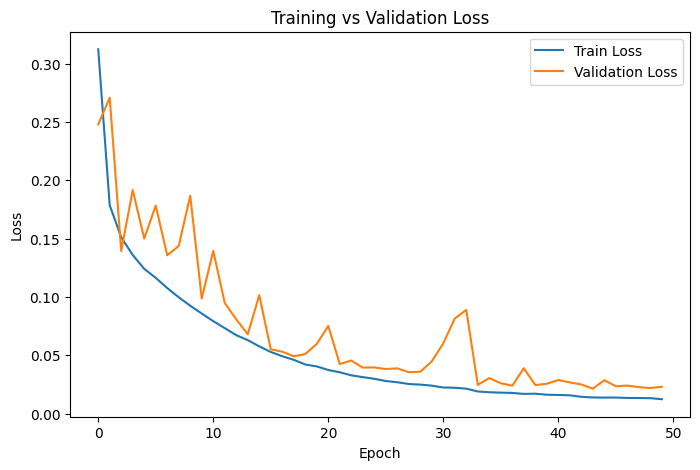

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_lstm.history["loss"],label="Train Loss")
plt.plot(history_lstm.history["val_loss"],label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [18]:
optimizer_gru = Adam(learning_rate=0.0005)

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    GRU(256, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),

    GRU(128, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.4),

    GRU(96, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(32, return_sequences=True, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    GRU(16, kernel_regularizer=l2(1e-4)),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(1e-4)),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(
    optimizer=optimizer_gru,
    loss="mse",
    metrics=["mae"]
)

buf = io.StringIO()
gru_model.summary(print_fn=lambda x: buf.write(x + "\n"))
print(buf.getvalue())

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 256)        │       217,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 30, 128)        │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 30, 96)         │        65,088 │
├─────────────────────────────────┼───────────────────

In [50]:
from pathlib import Path
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.models import load_model

# CHECK 1: Skip training if trained model already exists
gru_path = Path("models/gru_rul_model.keras")
if gru_path.exists():
    gru_model = load_model(gru_path)
    print(f"✓ GRU model already trained. Loaded from {gru_path}")
    print("  (Training skipped; to retrain, delete the saved model file)")
else:
    # CHECK 2: Ensure training data is available
    required_training_arrays = ["X_train", "y_train", "X_val", "y_val"]
    missing_arrays = [name for name in required_training_arrays if name not in globals()]
    if missing_arrays:
        raise RuntimeError(
            "Missing training arrays: " + ", ".join(missing_arrays) + ". "
            "Run preprocessing/sequence cells first."
        )

    if "gru_model" not in globals():
        raise RuntimeError(
            "gru_model is not defined. Run the GRU architecture cell first."
        )

    print("Training GRU model...")
    history_gru = gru_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=256,
        callbacks=make_training_callbacks("gru")
    )

    gru_model.save("models/gru_rul_model.keras")
    print("✓ Saved GRU model to models/gru_rul_model.keras")

✓ GRU model already trained. Loaded from models\gru_rul_model.keras
  (Training skipped; to retrain, delete the saved model file)


In [20]:
from pathlib import Path
from keras.models import load_model

if "MAX_RUL" not in globals():
    MAX_RUL = 125

if "X_val" not in globals() or "y_val" not in globals():
    required_inputs = ["val_df", "feature_cols", "window_size", "sequence_stride"]
    missing_inputs = [name for name in required_inputs if name not in globals()]
    if missing_inputs:
        raise RuntimeError(
            "Missing prerequisites for validation inference: "
            + ", ".join(missing_inputs)
            + ". Run the preprocessing cells first."
        )
    X_val, y_val = create_sequences(val_df)
    print(f"Prepared validation sequences from val_df: X_val={X_val.shape}, y_val={y_val.shape}")

if "lstm_model" not in globals():
    lstm_path = Path("models/lstm_rul_model.keras")
    if not lstm_path.exists():
        raise RuntimeError("LSTM model not found in memory or at models/lstm_rul_model.keras")
    lstm_model = load_model(lstm_path)
    print(f"Loaded LSTM model from {lstm_path}")

if "gru_model" not in globals():
    gru_path = Path("models/gru_rul_model.keras")
    if not gru_path.exists():
        raise RuntimeError("GRU model not found in memory or at models/gru_rul_model.keras")
    gru_model = load_model(gru_path)
    print(f"Loaded GRU model from {gru_path}")

y_pred_lstm = lstm_model.predict(X_val).flatten()
y_pred_gru  = gru_model.predict(X_val).flatten()

# Scale back to original RUL range for interpretable metrics
y_val_orig       = y_val        * MAX_RUL
y_pred_lstm_orig = y_pred_lstm  * MAX_RUL
y_pred_gru_orig  = y_pred_gru   * MAX_RUL

# LSTM metrics
rmse_lstm = np.sqrt(mean_squared_error(y_val_orig, y_pred_lstm_orig))
mae_lstm  = mean_absolute_error(y_val_orig, y_pred_lstm_orig)
r2_lstm   = r2_score(y_val_orig, y_pred_lstm_orig)

# GRU metrics
rmse_gru = np.sqrt(mean_squared_error(y_val_orig, y_pred_gru_orig))
mae_gru  = mean_absolute_error(y_val_orig, y_pred_gru_orig)
r2_gru   = r2_score(y_val_orig, y_pred_gru_orig)

print(f"{'Metric':<10} {'LSTM':>10} {'GRU':>10}")
print("-" * 32)
print(f"{'RMSE':<10} {rmse_lstm:>10.4f} {rmse_gru:>10.4f}")
print(f"{'MAE':<10} {mae_lstm:>10.4f} {mae_gru:>10.4f}")
print(f"{'R²':<10} {r2_lstm:>10.4f} {r2_gru:>10.4f}")

428/428 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step
428/428 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step
Metric           LSTM        GRU
--------------------------------
RMSE          16.4958    15.7197
MAE           12.1768    11.2442
R²             0.8445     0.8588


In [21]:
better = "LSTM" if rmse_lstm < rmse_gru else "GRU"
print(f"{better} performs better overall")
print(f"  RMSE  → LSTM: {rmse_lstm:.4f}  |  GRU: {rmse_gru:.4f}")
print(f"  MAE   → LSTM: {mae_lstm:.4f}  |  GRU: {mae_gru:.4f}")
print(f"  R²    → LSTM: {r2_lstm:.4f}  |  GRU: {r2_gru:.4f}")

GRU performs better overall
  RMSE  → LSTM: 16.4958  |  GRU: 15.7197
  MAE   → LSTM: 12.1768  |  GRU: 11.2442
  R²    → LSTM: 0.8445  |  GRU: 0.8588


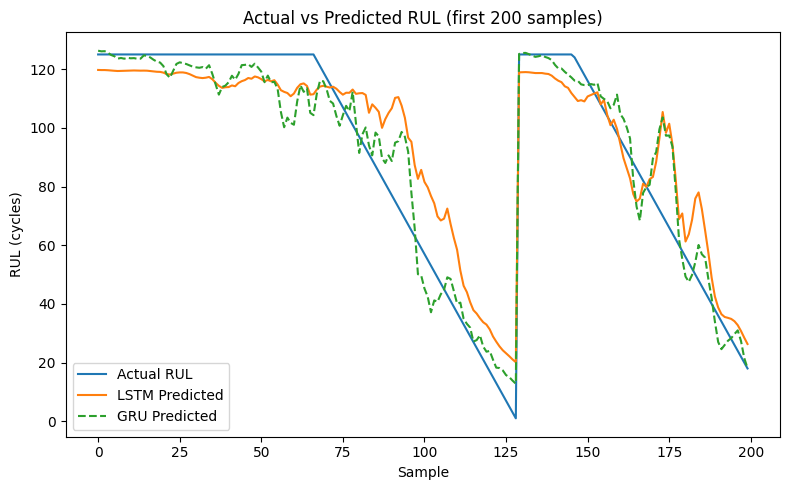

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(y_val_orig[:200],        label="Actual RUL")
plt.plot(y_pred_lstm_orig[:200],  label="LSTM Predicted")
plt.plot(y_pred_gru_orig[:200],   label="GRU Predicted", linestyle="--")

plt.title("Actual vs Predicted RUL (first 200 samples)")
plt.xlabel("Sample")
plt.ylabel("RUL (cycles)")
plt.legend()
plt.tight_layout()
plt.show()

## Milestone 3: Model Evaluation and Performance Assessment


In [23]:
test_frames = []

for ds in ["FD001", "FD002", "FD003", "FD004"]:
    test_path = f"data/test_{ds}.txt"
    rul_path = f"data/RUL_{ds}.txt"

    tdf = pd.read_csv(test_path, sep=" ", header=None).dropna(axis=1)
    tdf.columns = columns
    tdf["dataset"] = ds
    tdf["unit_id"] = tdf["dataset"] + "_" + tdf["unit"].astype(str)

    rul_df = pd.read_csv(rul_path, sep=" ", header=None).dropna(axis=1)
    unit_to_final_rul = {idx + 1: int(val) for idx, val in enumerate(rul_df.iloc[:, 0].tolist())}

    max_cycle_test = tdf.groupby("unit_id", as_index=False)["cycle"].max()
    max_cycle_test["unit"] = max_cycle_test["unit_id"].str.split("_").str[1].astype(int)
    max_cycle_test["final_rul"] = max_cycle_test["unit"].map(unit_to_final_rul)
    max_cycle_test["failure_cycle"] = max_cycle_test["cycle"] + max_cycle_test["final_rul"]

    tdf = tdf.merge(max_cycle_test[["unit_id", "failure_cycle"]], on="unit_id", how="left")
    tdf["RUL"] = tdf["failure_cycle"] - tdf["cycle"]
    tdf.drop(columns=["failure_cycle"], inplace=True)

    test_frames.append(tdf)

test_df = pd.concat(test_frames, ignore_index=True)

missing_cols = [c for c in feature_cols if c not in test_df.columns]
if missing_cols:
    raise ValueError(f"Missing required feature columns in test data: {missing_cols}")

# Keep original cycle index for timeline visualization before feature scaling.
test_df["cycle_raw"] = test_df["cycle"]

test_df[feature_cols] = test_df[feature_cols].astype(float)
test_df.loc[:, feature_cols] = scaler.transform(test_df[feature_cols])
test_df["RUL_norm"] = test_df["RUL"].clip(upper=MAX_RUL) / MAX_RUL

print("Combined Test Shape:", test_df.shape)
print("Unique test engines:", test_df["unit_id"].nunique())
print("RUL range (raw):", (test_df["RUL"].min(), test_df["RUL"].max()))

Combined Test Shape: (104897, 31)
Unique test engines: 707
RUL range (raw): (np.int64(6), np.int64(553))


In [30]:
from pathlib import Path
from keras.models import load_model
import json

if "window_size" not in globals():
    window_size = 30
if "sequence_stride" not in globals():
    sequence_stride = 2

required_inputs = ["test_df", "feature_cols", "MAX_RUL"]
missing_inputs = [name for name in required_inputs if name not in globals()]
if missing_inputs:
    raise RuntimeError(
        "Missing prerequisites for evaluation: "
        + ", ".join(missing_inputs)
        + ". Run test-data preparation first."
    )

if "lstm_model" not in globals() or "gru_model" not in globals():
    lstm_path = Path("models/lstm_rul_model.keras")
    gru_path = Path("models/gru_rul_model.keras")

    if not lstm_path.exists() or not gru_path.exists():
        raise RuntimeError(
            "lstm_model/gru_model are not in memory, and saved model files are missing. "
            "Run model training cells first or place models in models/."
        )

    if "lstm_model" not in globals():
        lstm_model = load_model(lstm_path)
        print(f"Loaded LSTM model from {lstm_path}")

    if "gru_model" not in globals():
        gru_model = load_model(gru_path)
        print(f"Loaded GRU model from {gru_path}")

def create_test_sequences(data):
    X, y, meta = [], [], []

    for uid in data["unit_id"].unique():
        engine = data[data["unit_id"] == uid].sort_values("cycle_raw")

        if len(engine) < window_size:
            continue

        for i in range(0, len(engine) - window_size + 1, sequence_stride):
            end_idx = i + window_size - 1
            X.append(engine[feature_cols].iloc[i:i + window_size].values)
            y.append(engine["RUL_norm"].iloc[end_idx])
            meta.append(
                {
                    "dataset": engine["dataset"].iloc[0],
                    "unit_id": uid,
                    "cycle": int(engine["cycle_raw"].iloc[end_idx])
                }
            )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        pd.DataFrame(meta)
    )

X_test, y_test, test_meta = create_test_sequences(test_df)
if len(X_test) == 0:
    raise RuntimeError("No test sequences were created. Check window_size/stride and test_df.")

y_test_pred_lstm = lstm_model.predict(X_test).flatten()
y_test_pred_gru = gru_model.predict(X_test).flatten()

y_test_orig = y_test * MAX_RUL
y_test_pred_lstm_orig = y_test_pred_lstm * MAX_RUL
y_test_pred_gru_orig = y_test_pred_gru * MAX_RUL

results_df = test_meta.copy()
results_df["actual_rul"] = y_test_orig
results_df["pred_lstm"] = y_test_pred_lstm_orig
results_df["pred_gru"] = y_test_pred_gru_orig
results_df["residual_lstm"] = results_df["pred_lstm"] - results_df["actual_rul"]
results_df["residual_gru"] = results_df["pred_gru"] - results_df["actual_rul"]

1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step


In [31]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred))
    }

overall_lstm = regression_metrics(y_test_orig, y_test_pred_lstm_orig)
overall_gru = regression_metrics(y_test_orig, y_test_pred_gru_orig)

print("Overall Test Metrics")
print(f"{'Metric':<10} {'LSTM':>12} {'GRU':>12}")
print("-" * 36)
for metric in ["RMSE", "MAE", "R2"]:
    print(f"{metric:<10} {overall_lstm[metric]:>12.4f} {overall_gru[metric]:>12.4f}")

per_dataset_rows = []
for ds, part in results_df.groupby("dataset"):
    m_lstm = regression_metrics(part["actual_rul"], part["pred_lstm"])
    m_gru = regression_metrics(part["actual_rul"], part["pred_gru"])
    per_dataset_rows.append(
        {
            "dataset": ds
            ,"lstm_rmse": m_lstm["RMSE"]
            ,"gru_rmse": m_gru["RMSE"]
            ,"lstm_mae": m_lstm["MAE"]
            ,"gru_mae": m_gru["MAE"]
            ,"lstm_r2": m_lstm["R2"]
            ,"gru_r2": m_gru["R2"]
        }
    )

per_dataset_metrics = pd.DataFrame(per_dataset_rows).sort_values("dataset")
print("\nPer-Dataset Metrics")
display(per_dataset_metrics)

best_model_name = "LSTM" if overall_lstm["RMSE"] <= overall_gru["RMSE"] else "GRU"
results_df["pred_best"] = np.where(best_model_name == "LSTM", results_df["pred_lstm"], results_df["pred_gru"])
results_df["residual_best"] = results_df["pred_best"] - results_df["actual_rul"]

Overall Test Metrics
Metric             LSTM          GRU
------------------------------------
RMSE            16.1110      15.5710
MAE             11.2030      10.5974
R2               0.6886       0.7092

Per-Dataset Metrics


,dataset,lstm_rmse,gru_rmse,lstm_mae,gru_mae,lstm_r2,gru_r2
0,FD001,16.253702,15.740365,12.386356,10.707017,0.700387,0.719014
1,FD002,16.826028,16.579538,11.809073,12.042957,0.704879,0.713462
2,FD003,14.767360,13.116918,11.170042,8.348417,0.690560,0.755862
3,FD004,16.016373,15.618094,10.389909,10.343360,0.656453,0.673326


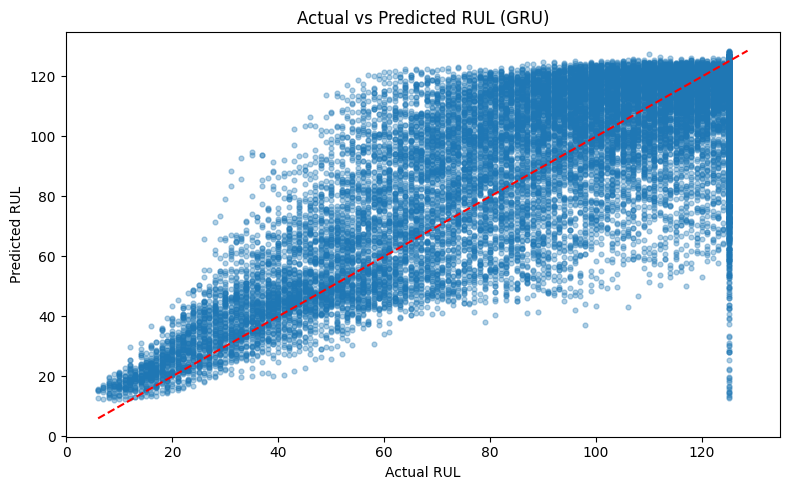

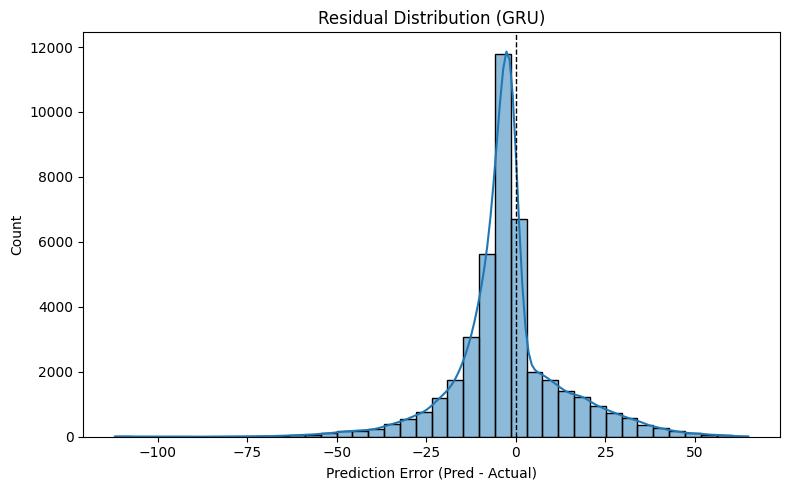

Residual bias (mean error): -2.3168 cycles
Residual spread (std):      15.3979 cycles


In [32]:
plt.figure(figsize=(8, 5))
plt.scatter(results_df["actual_rul"], results_df["pred_best"], alpha=0.35, s=12)
line_min = float(min(results_df["actual_rul"].min(), results_df["pred_best"].min()))
line_max = float(max(results_df["actual_rul"].max(), results_df["pred_best"].max()))
plt.plot([line_min, line_max], [line_min, line_max], color="red", linestyle="--", linewidth=1.5)
plt.title(f"Actual vs Predicted RUL ({best_model_name})")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(results_df["residual_best"], bins=40, kde=True)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title(f"Residual Distribution ({best_model_name})")
plt.xlabel("Prediction Error (Pred - Actual)")
plt.tight_layout()
plt.show()

residual_bias = results_df["residual_best"].mean()
residual_std = results_df["residual_best"].std()
print(f"Residual bias (mean error): {residual_bias:.4f} cycles")
print(f"Residual spread (std):      {residual_std:.4f} cycles")

In [33]:
# Persist evaluation outputs so later cells can run without recomputing everything.
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(artifacts_dir / "test_predictions_detailed.csv", index=False)
results_df[["dataset", "unit_id", "cycle", "actual_rul", "pred_best", "residual_best"]].to_csv(
    artifacts_dir / "test_predictions.csv",
    index=False
)
per_dataset_metrics.to_csv(artifacts_dir / "per_dataset_metrics.csv", index=False)

model_performance_report = {
    "overall_metrics": {
        "lstm": overall_lstm,
        "gru": overall_gru,
        "best_model": best_model_name
    },
    "per_dataset_metrics": per_dataset_metrics.to_dict(orient="records")
}
with open(artifacts_dir / "model_performance_report.json", "w", encoding="utf-8") as f:
    json.dump(model_performance_report, f, indent=2)

print("Saved evaluation artifacts:")
print(f"  - {artifacts_dir / 'test_predictions_detailed.csv'}")
print(f"  - {artifacts_dir / 'test_predictions.csv'}")
print(f"  - {artifacts_dir / 'per_dataset_metrics.csv'}")
print(f"  - {artifacts_dir / 'model_performance_report.json'}")

Saved evaluation artifacts:
  - artifacts\test_predictions_detailed.csv
  - artifacts\test_predictions.csv
  - artifacts\per_dataset_metrics.csv
  - artifacts\model_performance_report.json


In [51]:
# Part 1: LSTM + GRU machine health classification preparation
CRITICAL_RUL_THRESHOLD = 30
WARNING_RUL_THRESHOLD = 60

if "results_df" not in globals():
    artifact_path = "artifacts/test_predictions_detailed.csv"
    try:
        results_df = pd.read_csv(artifact_path)
        print(f"Loaded results_df from {artifact_path} (shape={results_df.shape})")
    except Exception as exc:
        raise RuntimeError(
            "results_df is missing. Run the Milestone 3 evaluation cells first, "
            "or ensure artifacts/test_predictions_detailed.csv exists."
        ) from exc

required_cols = {"dataset", "unit_id", "cycle", "pred_lstm", "pred_gru"}
missing_cols = required_cols - set(results_df.columns)
if missing_cols:
    raise ValueError(f"results_df is missing required columns: {sorted(missing_cols)}")

def classify_condition(predicted_rul):
    if predicted_rul <= CRITICAL_RUL_THRESHOLD:
        return "CRITICAL"
    if predicted_rul <= WARNING_RUL_THRESHOLD:
        return "WARNING"
    return "HEALTHY"

results_df["lstm_alert_level"] = results_df["pred_lstm"].apply(classify_condition)
results_df["gru_alert_level"] = results_df["pred_gru"].apply(classify_condition)
results_df["consensus_predicted_rul"] = (results_df["pred_lstm"] + results_df["pred_gru"]) / 2.0
results_df["consensus_alert_level"] = results_df["consensus_predicted_rul"].apply(classify_condition)

latest_dual_status = (
    results_df.sort_values(["unit_id", "cycle"])
    .groupby(["dataset", "unit_id"], as_index=False)
    .tail(1)
    .loc[:, [
        "dataset",
        "unit_id",
        "cycle",
        "pred_lstm",
        "pred_gru",
        "consensus_predicted_rul",
        "lstm_alert_level",
        "gru_alert_level",
        "consensus_alert_level",
    ]]
    .rename(columns={
        "cycle": "latest_cycle",
        "pred_lstm": "lstm_predicted_rul",
        "pred_gru": "gru_predicted_rul",
    })
    .sort_values(["dataset", "unit_id"])
    .reset_index(drop=True)
)

latest_dual_status["alert_disagreement"] = (
    latest_dual_status["lstm_alert_level"] != latest_dual_status["gru_alert_level"]
)

# Backward-compatible GRU-only view used by existing downstream snippets.
latest_gru_status = latest_dual_status[
    ["dataset", "unit_id", "latest_cycle", "gru_predicted_rul", "gru_alert_level"]
].rename(columns={"gru_predicted_rul": "predicted_rul"})

In [45]:
# Part 2: Threshold legend and latest engine status (LSTM, GRU, consensus)
print("Predicted RUL -> Machine Condition")
print(f"  CRITICAL: predicted_rul <= {CRITICAL_RUL_THRESHOLD}")
print(f"  WARNING : {CRITICAL_RUL_THRESHOLD} < predicted_rul <= {WARNING_RUL_THRESHOLD}")
print(f"  HEALTHY : predicted_rul > {WARNING_RUL_THRESHOLD}")

print("\nLatest status per engine (LSTM, GRU, consensus):")
display(latest_dual_status.head(20))

Predicted RUL -> Machine Condition
  CRITICAL: predicted_rul <= 30
  HEALTHY : predicted_rul > 60

Latest status per engine (LSTM, GRU, consensus):


,dataset,unit_id,latest_cycle,lstm_predicted_rul,gru_predicted_rul,consensus_predicted_rul,lstm_alert_level,gru_alert_level,consensus_alert_level,alert_disagreement
0,FD001,FD001_1,30,118.792877,124.827667,121.810272,HEALTHY,HEALTHY,HEALTHY,False
1,FD001,FD001_10,192,100.010979,103.626656,101.818817,HEALTHY,HEALTHY,HEALTHY,False
2,FD001,FD001_100,198,29.573261,17.518442,23.545853,CRITICAL,CRITICAL,CRITICAL,False
3,FD001,FD001_11,82,92.966286,110.049309,101.507797,HEALTHY,HEALTHY,HEALTHY,False
4,FD001,FD001_12,216,112.494316,113.046165,112.770241,HEALTHY,HEALTHY,HEALTHY,False
5,FD001,FD001_13,194,89.475456,94.816582,92.146019,HEALTHY,HEALTHY,HEALTHY,False
6,FD001,FD001_14,46,113.165291,120.603401,116.884346,HEALTHY,HEALTHY,HEALTHY,False
7,FD001,FD001_15,76,103.488106,106.398643,104.943375,HEALTHY,HEALTHY,HEALTHY,False
8,FD001,FD001_16,112,92.979637,110.866440,101.923035,HEALTHY,HEALTHY,HEALTHY,False
9,FD001,FD001_17,164,46.583809,44.865700,45.724754,WARNING,WARNING,WARNING,False


In [52]:
# Part 3: Engine condition summary by model + disagreement count
alert_order = ["CRITICAL", "WARNING", "HEALTHY"]

lstm_alert_counts = (
    latest_dual_status["lstm_alert_level"]
    .value_counts()
    .reindex(alert_order, fill_value=0)
    .rename_axis("condition")
    .reset_index(name="engine_count")
)
lstm_alert_counts["source"] = "LSTM"

gru_alert_counts = (
    latest_dual_status["gru_alert_level"]
    .value_counts()
    .reindex(alert_order, fill_value=0)
    .rename_axis("condition")
    .reset_index(name="engine_count")
)
gru_alert_counts["source"] = "GRU"

consensus_alert_counts = (
    latest_dual_status["consensus_alert_level"]
    .value_counts()
    .reindex(alert_order, fill_value=0)
    .rename_axis("condition")
    .reset_index(name="engine_count")
)
consensus_alert_counts["source"] = "CONSENSUS"

alert_counts_by_source = pd.concat(
    [lstm_alert_counts, gru_alert_counts, consensus_alert_counts],
    ignore_index=True
)[ ["source", "condition", "engine_count"] ]

# Backward-compatible summary (same shape as previous GRU-only output).
alert_counts = gru_alert_counts[["condition", "engine_count"]].copy()

disagreement_count = int(latest_dual_status["alert_disagreement"].sum())
print(f"\nModel alert disagreements (LSTM vs GRU): {disagreement_count}")

print("\nEngine condition summary by source:")
display(alert_counts_by_source)

print("\nGRU-only summary (compatible with earlier cells):")
display(alert_counts)


Model alert disagreements (LSTM vs GRU): 54

Engine condition summary by source:


,source,condition,engine_count
0,LSTM,CRITICAL,119
1,LSTM,WARNING,131
2,LSTM,HEALTHY,440
3,GRU,CRITICAL,142
4,GRU,WARNING,113
5,GRU,HEALTHY,435
6,CONSENSUS,CRITICAL,132
7,CONSENSUS,WARNING,122
8,CONSENSUS,HEALTHY,436



GRU-only summary (compatible with earlier cells):


,condition,engine_count
0,CRITICAL,142
1,WARNING,113
2,HEALTHY,435


In [47]:
# Part 4: Immediate attention list (critical by either model or consensus)
critical_now = latest_dual_status[
    (latest_dual_status["lstm_alert_level"] == "CRITICAL")
    | (latest_dual_status["gru_alert_level"] == "CRITICAL")
    | (latest_dual_status["consensus_alert_level"] == "CRITICAL")
]

if not critical_now.empty:
    print("\nImmediate attention required (CRITICAL by LSTM/GRU/consensus):")
    display(
        critical_now[
            [
                "dataset",
                "unit_id",
                "latest_cycle",
                "lstm_predicted_rul",
                "gru_predicted_rul",
                "consensus_predicted_rul",
                "lstm_alert_level",
                "gru_alert_level",
                "consensus_alert_level",
                "alert_disagreement",
            ]
        ].head(20)
    )
else:
    print("\nNo engines are in CRITICAL condition right now.")


Immediate attention required (CRITICAL by LSTM/GRU/consensus):


,dataset,unit_id,latest_cycle,lstm_predicted_rul,gru_predicted_rul,consensus_predicted_rul,lstm_alert_level,gru_alert_level,consensus_alert_level,alert_disagreement
2,FD001,FD001_100,198,29.573261,17.518442,23.545853,CRITICAL,CRITICAL,CRITICAL,False
10,FD001,FD001_18,132,32.022621,29.186609,30.604614,WARNING,CRITICAL,WARNING,True
13,FD001,FD001_20,184,26.946074,21.622435,24.284254,CRITICAL,CRITICAL,CRITICAL,False
17,FD001,FD001_24,186,30.861813,21.107807,25.984810,WARNING,CRITICAL,CRITICAL,True
25,FD001,FD001_31,196,21.612452,16.298208,18.955330,CRITICAL,CRITICAL,CRITICAL,False
28,FD001,FD001_34,202,21.217728,14.349431,17.783579,CRITICAL,CRITICAL,CRITICAL,False
29,FD001,FD001_35,198,22.098812,18.041407,20.070110,CRITICAL,CRITICAL,CRITICAL,False
30,FD001,FD001_36,126,28.441221,21.627821,25.034521,CRITICAL,CRITICAL,CRITICAL,False
36,FD001,FD001_41,122,23.681118,15.231829,19.456474,CRITICAL,CRITICAL,CRITICAL,False
37,FD001,FD001_42,156,23.409485,16.893562,20.151524,CRITICAL,CRITICAL,CRITICAL,False


## Milestone 4: Advanced Model Analysis & Interpretability

Prediction Accuracy by RUL Range:
             Count     RMSE      MAE      R2
rul_range                                   
0-30        1295.0  10.1627   8.0101 -1.7298
30-60       3235.0  19.8172  14.3807 -4.3361
60-90       4887.0  23.8205  20.2890 -6.5912
90+        33008.0  13.6043   8.8932 -1.4829


C:\Users\vurit\AppData\Local\Temp\ipykernel_25320\2369424690.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temporal_analysis = results_df.groupby("rul_range", observed=False).apply(


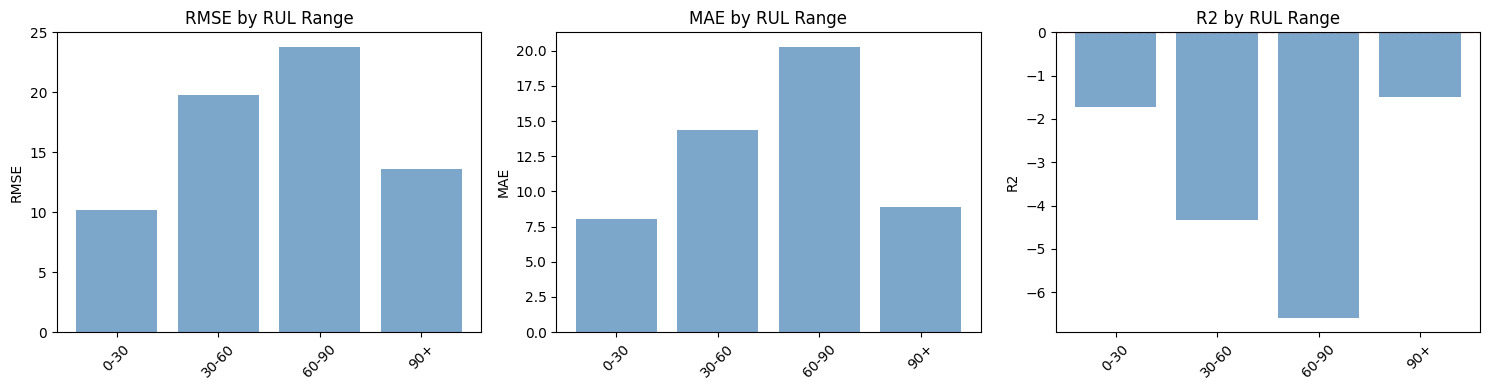

In [ ]:
# ────── Temporal Prediction Accuracy Analysis ──────────────────────────
# Analyze prediction accuracy across different RUL ranges

if "results_df" not in globals():
    artifact_path = "artifacts/test_predictions_detailed.csv"
    try:
        results_df = pd.read_csv(artifact_path)
        print(f"Loaded results_df from {artifact_path} (shape={results_df.shape})")
    except Exception as exc:
        raise RuntimeError(
            "results_df is missing. Run the Milestone 3 evaluation cells first, "
            "or ensure artifacts/test_predictions_detailed.csv exists."
        ) from exc

required_cols = {"actual_rul", "pred_best"}
missing_cols = required_cols - set(results_df.columns)
if missing_cols:
    raise ValueError(f"results_df is missing required columns: {sorted(missing_cols)}")

rul_bins = [0, 30, 60, 90, 125]
rul_labels = ["0-30", "30-60", "60-90", "90+"]

results_df["rul_range"] = pd.cut(
    results_df["actual_rul"],
    bins=rul_bins,
    labels=rul_labels,
    include_lowest=True
)

temporal_analysis = results_df.groupby("rul_range", observed=False).apply(
    lambda x: pd.Series({
        "Count": len(x),
        "RMSE": np.sqrt(mean_squared_error(x["actual_rul"], x["pred_best"])),
        "MAE": mean_absolute_error(x["actual_rul"], x["pred_best"]),
        "R2": r2_score(x["actual_rul"], x["pred_best"]) if len(x) > 1 else 0
    })
).round(4)

print("Prediction Accuracy by RUL Range:")
print(temporal_analysis)

# Visualize temporal accuracy variation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, metric in enumerate(["RMSE", "MAE", "R2"]):
    axes[idx].bar(range(len(temporal_analysis)), temporal_analysis[metric], color="steelblue", alpha=0.7)
    axes[idx].set_xticks(range(len(temporal_analysis)))
    axes[idx].set_xticklabels(temporal_analysis.index, rotation=45)
    axes[idx].set_title(f"{metric} by RUL Range")
    axes[idx].set_ylabel(metric)
    if metric == "R2":
        axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\vurit\AppData\Local\Temp\ipykernel_25320\2048013602.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  engine_performance = results_df.groupby("unit_id").apply(



Top 10 Engines with Highest RMSE (Most Challenging):
           Samples  Avg_Actual_RUL     RMSE      MAE        R2  Max_Error  \
unit_id                                                                     
FD004_206    131.0        124.5115  45.2463  30.9460 -412.4001   112.0541   
FD004_180    169.0        112.2071  42.5401  28.9043   -1.8747   110.5163   
FD004_77      40.0         64.0000  40.1744  38.1746   -2.0281    59.9609   
FD003_89      46.0         85.7391  38.2020  32.1927   -1.1356    64.0084   
FD002_121     15.0         82.0000  37.4565  37.2266  -17.7900    43.7147   
FD004_198     43.0         54.0000  37.2116  35.1293   -1.2479    52.4161   
FD002_111     51.0         60.0000  37.0410  32.8386   -0.5831    61.9977   
FD001_41      47.0         65.0000  36.5720  33.6225   -0.8173    52.7467   
FD002_102     47.0         54.0000  34.7097  31.0454   -0.6369    57.6989   
FD002_173     44.0         58.0000  33.9243  30.0246   -0.7843    56.7543   

              Bias  


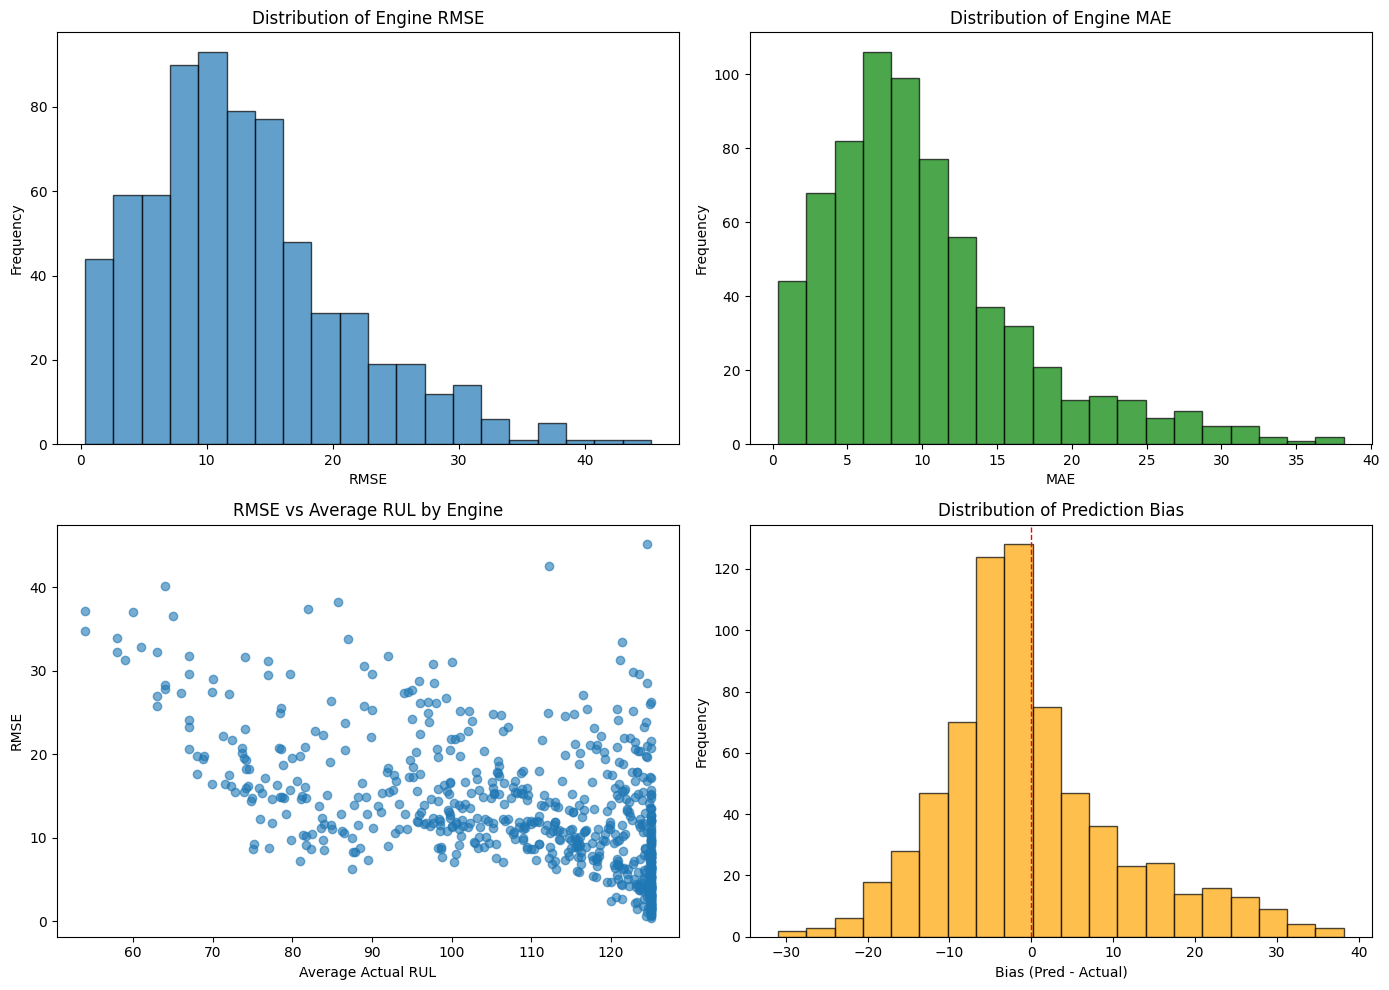

In [27]:
# ────── Engine-Level Performance Evaluation ──────────────────────────
# Assess per-engine prediction accuracy to identify problem units

engine_performance = results_df.groupby("unit_id").apply(
    lambda x: pd.Series({
        "Samples": len(x),
        "Avg_Actual_RUL": x["actual_rul"].mean(),
        "RMSE": np.sqrt(mean_squared_error(x["actual_rul"], x["pred_best"])),
        "MAE": mean_absolute_error(x["actual_rul"], x["pred_best"]),
        "R2": r2_score(x["actual_rul"], x["pred_best"]) if len(x) > 1 else 0,
        "Max_Error": (x["pred_best"] - x["actual_rul"]).abs().max(),
        "Bias": (x["pred_best"] - x["actual_rul"]).mean()
    })
).round(4).sort_values("RMSE", ascending=False)

print("\nTop 10 Engines with Highest RMSE (Most Challenging):")
print(engine_performance.head(10))

print("\nTop 10 Engines with Lowest RMSE (Most Accurate):")
print(engine_performance.tail(10))

# Visualize engine-level performance distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(engine_performance["RMSE"], bins=20, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of Engine RMSE")
axes[0, 0].set_xlabel("RMSE")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].hist(engine_performance["MAE"], bins=20, edgecolor="black", alpha=0.7, color="green")
axes[0, 1].set_title("Distribution of Engine MAE")
axes[0, 1].set_xlabel("MAE")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].scatter(engine_performance["Avg_Actual_RUL"], engine_performance["RMSE"], alpha=0.6)
axes[1, 0].set_title("RMSE vs Average RUL by Engine")
axes[1, 0].set_xlabel("Average Actual RUL")
axes[1, 0].set_ylabel("RMSE")

axes[1, 1].hist(engine_performance["Bias"], bins=20, edgecolor="black", alpha=0.7, color="orange")
axes[1, 1].set_title("Distribution of Prediction Bias")
axes[1, 1].set_xlabel("Bias (Pred - Actual)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Prediction Interval Coverage Probability (PICP) @ 95%: 0.2817
Average Prediction Std Dev: 3.1450
Average Prediction Interval Width: 12.3283


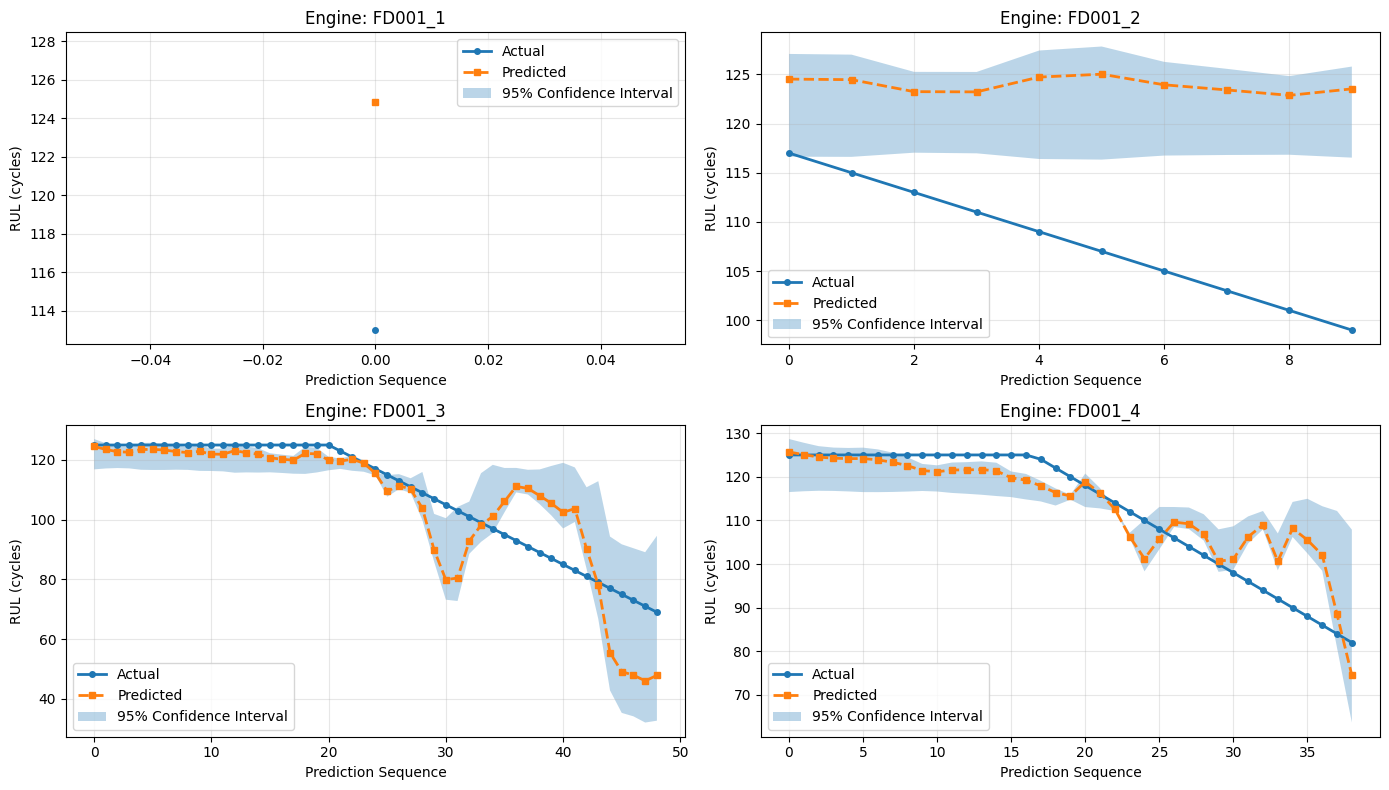

Saved summary artifact: artifacts\model_summary_stats.json


In [28]:
# Prediction uncertainty quantification
from pathlib import Path
import json

# Use the ensemble of LSTM and GRU as a simple uncertainty proxy
ensemble_pred_std = np.abs(results_df["pred_lstm"] - results_df["pred_gru"]) / 2
ensemble_pred_mean = (results_df["pred_lstm"] + results_df["pred_gru"]) / 2

results_df["pred_std"] = ensemble_pred_std
results_df["pred_lower_95"] = ensemble_pred_mean - 1.96 * ensemble_pred_std
results_df["pred_upper_95"] = ensemble_pred_mean + 1.96 * ensemble_pred_std

# Calculate prediction interval coverage probability (PICP)
coverage = (
    (results_df["actual_rul"] >= results_df["pred_lower_95"])
    & (results_df["actual_rul"] <= results_df["pred_upper_95"])
).sum() / len(results_df)

print(f"Prediction Interval Coverage Probability (PICP) @ 95%: {coverage:.4f}")
print(f"Average Prediction Std Dev: {ensemble_pred_std.mean():.4f}")
print(f"Average Prediction Interval Width: {(results_df['pred_upper_95'] - results_df['pred_lower_95']).mean():.4f}")

# Visualize uncertainty bands for sample engines
sample_engines = results_df["unit_id"].unique()[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, engine in enumerate(sample_engines):
    engine_data = results_df[results_df["unit_id"] == engine].sort_values("cycle").reset_index(drop=True)

    axes[idx].plot(engine_data.index, engine_data["actual_rul"], "o-", label="Actual", linewidth=2, markersize=4)
    axes[idx].plot(engine_data.index, engine_data["pred_best"], "s--", label="Predicted", linewidth=2, markersize=4)
    axes[idx].fill_between(
        engine_data.index,
        engine_data["pred_lower_95"],
        engine_data["pred_upper_95"],
        alpha=0.3,
        label="95% Confidence Interval"
    )

    axes[idx].set_title(f"Engine: {engine}")
    axes[idx].set_xlabel("Prediction Sequence")
    axes[idx].set_ylabel("RUL (cycles)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Persist summary statistics for reporting.
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

summary_payload = {
    "metrics_overview": {
        "best_model": str(best_model_name) if "best_model_name" in globals() else "Unknown",
        "best_model_rmse": float(min(overall_lstm["RMSE"], overall_gru["RMSE"])) if "overall_lstm" in globals() and "overall_gru" in globals() else None,
        "avg_prediction_error_cycles": float(results_df["residual_best"].abs().mean()) if "residual_best" in results_df.columns else None,
        "median_prediction_error_cycles": float(results_df["residual_best"].abs().median()) if "residual_best" in results_df.columns else None,
        "std_prediction_error": float(results_df["residual_best"].std()) if "residual_best" in results_df.columns else None,
        "prediction_intervals_coverage_95": float(coverage)
    },
    "dataset_summary": {
        "num_test_samples": int(len(results_df)),
        "num_engines_evaluated": int(results_df["unit_id"].nunique()),
        "datasets": sorted(results_df["dataset"].unique().tolist())
    }
}

if "temporal_analysis" in globals():
    summary_payload["performance_by_rul_range"] = {
        str(idx): {k: float(v) for k, v in row.items()}
        for idx, row in temporal_analysis.to_dict(orient="index").items()
    }

if "engine_performance" in globals():
    summary_payload["model_reliability"] = {
        "engines_excellent_accuracy": int((engine_performance["RMSE"] < 10).sum()),
        "engines_good_accuracy": int(((engine_performance["RMSE"] >= 10) & (engine_performance["RMSE"] < 15)).sum()),
        "engines_acceptable_accuracy": int(((engine_performance["RMSE"] >= 15) & (engine_performance["RMSE"] < 25)).sum()),
        "engines_poor_accuracy": int((engine_performance["RMSE"] >= 25).sum())
    }

with open(artifacts_dir / "model_summary_stats.json", "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print(f"Saved summary artifact: {artifacts_dir / 'model_summary_stats.json'}")

## Milestone 5: Deployment-Ready Monitoring & Dashboard Artifacts

In [29]:
from pathlib import Path

# Build dashboard-ready artifacts from available evaluation outputs (no retraining required).
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

if "results_df" not in globals():
    detailed_path = artifacts_dir / "test_predictions_detailed.csv"
    if not detailed_path.exists():
        raise RuntimeError(
            "results_df is missing and artifacts/test_predictions_detailed.csv was not found. "
            "Run the test evaluation cell first."
        )
    results_df = pd.read_csv(detailed_path)
    print(f"Loaded results_df from {detailed_path} (shape={results_df.shape})")

required_dashboard_cols = [
    "dataset",
    "unit_id",
    "cycle",
    "actual_rul",
    "pred_lstm",
    "pred_gru",
    "residual_lstm",
    "residual_gru",
    "pred_best",
    "residual_best",
]
missing_dashboard_cols = [c for c in required_dashboard_cols if c not in results_df.columns]
if missing_dashboard_cols:
    raise ValueError(f"Missing required columns for Milestone 5 packaging: {missing_dashboard_cols}")

# Standardized alert levels for dashboard filtering and operations triage.
critical_threshold = 30
warning_threshold = 60

def alert_from_pred(predicted_rul):
    if predicted_rul <= critical_threshold:
        return "CRITICAL"
    if predicted_rul <= warning_threshold:
        return "WARNING"
    return "HEALTHY"

results_df["alert_level"] = results_df["pred_best"].apply(alert_from_pred)

dashboard_predictions = results_df[
    [
        "dataset", "unit_id", "cycle",
        "actual_rul", "pred_lstm", "pred_gru",
        "residual_lstm", "residual_gru",
        "pred_best", "residual_best", "alert_level"
    ]
].copy()

# Engine-level risk table prioritizes the lowest predicted remaining life per engine.
engine_risk = (
    dashboard_predictions.groupby(["dataset", "unit_id"], as_index=False)
    .agg(
        latest_cycle=("cycle", "max"),
        min_predicted_rul=("pred_best", "min"),
        latest_predicted_rul=("pred_best", "last"),
        mean_abs_error=("residual_best", lambda x: float(np.mean(np.abs(x)))),
        dominant_alert_level=("alert_level", lambda x: x.value_counts().idxmax())
    )
    .sort_values(["min_predicted_rul", "mean_abs_error"], ascending=[True, True])
    .reset_index(drop=True)
)

# Save Milestone 5 deployment artifacts.
dashboard_predictions.to_csv(artifacts_dir / "test_predictions.csv", index=False)
engine_risk.to_csv(artifacts_dir / "engine_risk.csv", index=False)

print("Milestone 5 artifacts saved:")
print(f"  - {artifacts_dir / 'test_predictions.csv'}")
print(f"  - {artifacts_dir / 'engine_risk.csv'}")
print("\nPreview: Top 10 high-risk engines")
display(engine_risk.head(10))

Milestone 5 artifacts saved:
  - artifacts\test_predictions.csv
  - artifacts\engine_risk.csv

Preview: Top 10 high-risk engines


,dataset,unit_id,latest_cycle,min_predicted_rul,latest_predicted_rul,mean_abs_error,dominant_alert_level
0,FD002,FD002_134,186,12.154077,12.154077,10.913160,HEALTHY
1,FD002,FD002_138,200,12.440633,12.440633,7.351717,HEALTHY
2,FD002,FD002_116,170,12.557037,12.711488,8.782369,HEALTHY
3,FD002,FD002_7,184,12.890677,12.890677,13.929817,HEALTHY
4,FD004,FD004_206,290,12.945910,105.999557,30.946035,HEALTHY
5,FD002,FD002_91,278,13.205886,13.595778,24.967602,HEALTHY
6,FD002,FD002_159,186,13.380196,13.380196,8.096652,HEALTHY
7,FD002,FD002_103,186,13.766091,13.766091,5.877376,HEALTHY
8,FD004,FD004_173,150,13.874665,13.874665,15.802502,HEALTHY
9,FD002,FD002_186,166,13.946865,13.946865,11.794214,HEALTHY


### Run Dashboard
After generating Milestone 5 artifacts, launch the dashboard with:
`streamlit run dashboard.py`

The dashboard reads:
- `artifacts/test_predictions.csv`
- `artifacts/per_dataset_metrics.csv`
- `artifacts/engine_risk.csv`